Transaction data injetion

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler 
from tensorflow.keras.models import Model 
from tensorflow.keras.layers import Input, Dense

data=pd.read_csv(r"C:\Users\Jasmine Rahaman\Desktop\vscode\jasmine\DataScienceProjects\credit_card_fraud_10k.csv")
df=pd.DataFrame(data)

Data Cleaning and Preprocessing

In [2]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df=df.dropna()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


Exploratory analysis of transaction behavior

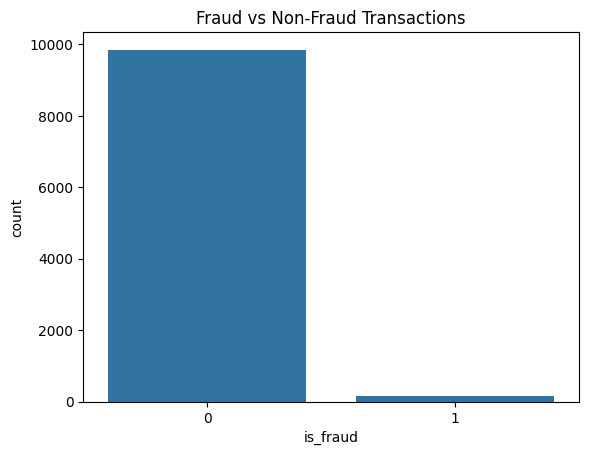

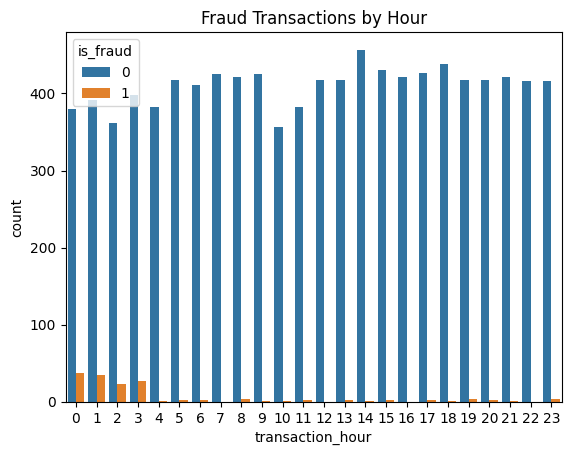

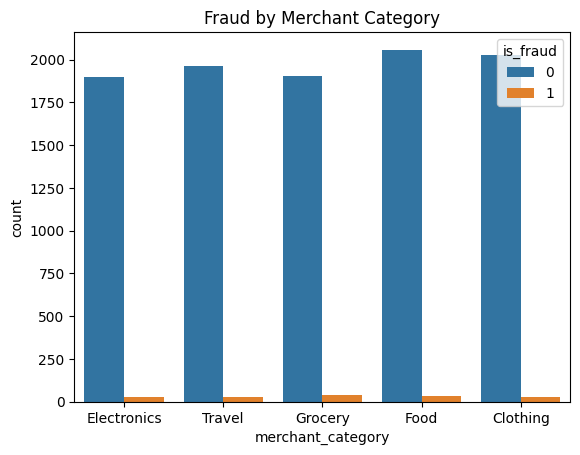

In [9]:
df['transaction_id'].value_counts()
#sns.countplot(x='merchant_category',data=df)

df['amount'].value_counts()
df['transaction_hour'].value_counts()
df['merchant_category'].value_counts()
df['foreign_transaction'].value_counts()
df['location_mismatch'].value_counts()
df['device_trust_score'].value_counts()
df['velocity_last_24h'].value_counts()
df['cardholder_age'].value_counts()
df['is_fraud'].value_counts()

sns.countplot(x='is_fraud', data=df) 
plt.title("Fraud vs Non-Fraud Transactions") 
plt.show() 

#Fraud by transaction hour 
sns.countplot(x='transaction_hour', hue='is_fraud', data=df) 
plt.title("Fraud Transactions by Hour") 
plt.show() 

#Fraud by merchant category 
sns.countplot(x='merchant_category', hue='is_fraud', data=df) 
plt.title("Fraud by Merchant Category") 
plt.show()


Feature engineering for fraud indicators

In [10]:
#Feature engineering
df['high_amount_flag']=(df['amount']>df['amount'].quantile(0.95).astype(int))
df['night_flag']=(df['transaction_hour'].apply(lambda x:1 if x<6 else 0))
df['velocity_flag']=(df['velocity_last_24h']>df['velocity_last_24h'].mean()).astype(int)




Fraud classification using analytics or ML models

In [12]:
#Fraud Classification
features = ['amount','transaction_hour','foreign_transaction',
           'location_mismatch','device_trust_score','velocity_last_24h',
            'cardholder_age','high_amount_flag','night_flag','velocity_flag']

X = df[features]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1969
           1       1.00      0.68      0.81        31

    accuracy                           0.99      2000
   macro avg       1.00      0.84      0.90      2000
weighted avg       1.00      0.99      0.99      2000

[[1969    0]
 [  10   21]]


Visualization of Fraud Trends

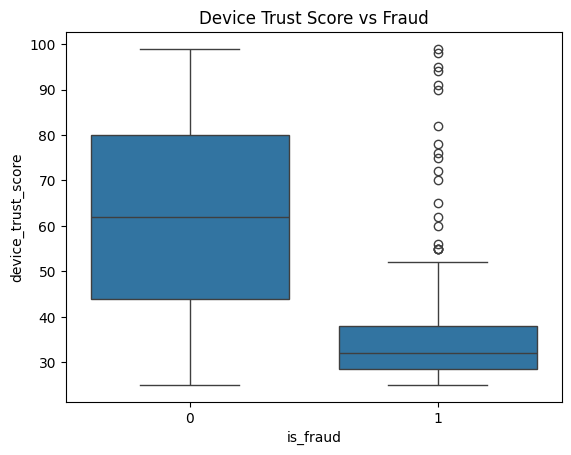

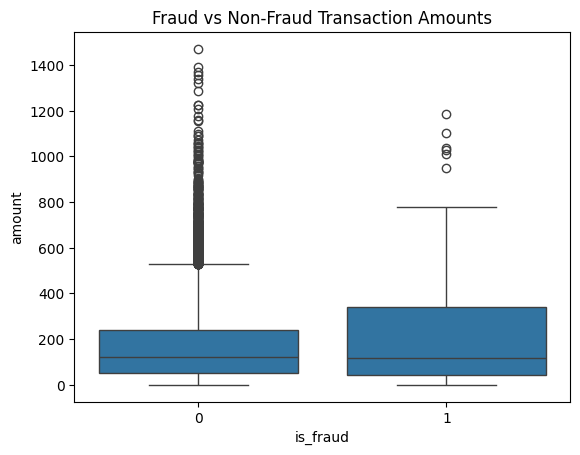

In [13]:
# Fraud by device trust score
sns.boxplot(x='is_fraud', y='device_trust_score', data=df)
plt.title("Device Trust Score vs Fraud")
plt.show()

# Fraud by transaction amount
sns.boxplot(x='is_fraud', y='amount', data=df)
plt.title("Fraud vs Non-Fraud Transaction Amounts")
plt.show()


Identification of Anomaly Patterns

In [14]:
features = ['amount','transaction_hour','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']

X = df[features]

# Train Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_score'] = iso.fit_predict(X)

# -1 = anomaly, 1 = normal
df['is_anomaly'] = (df['anomaly_score'] == -1).astype(int)

print(df[['transaction_id','amount','transaction_hour','is_anomaly']].head())
#-------------------------------------------------------------------
# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Build autoencoder
input_dim = X_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoder = Dense(8, activation="relu")(input_layer)
decoder = Dense(input_dim, activation="sigmoid")(encoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)

autoencoder.compile(optimizer="adam", loss="mse")

# Train autoencoder
autoencoder.fit(X_scaled, X_scaled, epochs=20, batch_size=32, shuffle=True, validation_split=0.1)

# Reconstruction error
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)
df['reconstruction_error'] = mse

# Flag anomalies
threshold = np.percentile(mse, 95)  # top 5% errors
df['is_anomaly_autoencoder'] = (df['reconstruction_error'] > threshold).astype(int)

print("Isolation Forest Performance:") 
print(confusion_matrix(df['is_fraud'], df['is_anomaly'])) 
print(classification_report(df['is_fraud'], df['is_anomaly'])) 
print("Autoencoder Performance:") 
print(confusion_matrix(df['is_fraud'], df['is_anomaly_autoencoder'])) 
print(classification_report(df['is_fraud'], df['is_anomaly_autoencoder']))


   transaction_id  amount  transaction_hour  is_anomaly
0               1   84.47                22           0
1               2  541.82                 3           1
2               3  237.01                17           0
3               4  164.33                 4           0
4               5   30.53                15           0
Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0929 - val_loss: 0.0621
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0529 - val_loss: 0.0442
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0380 - val_loss: 0.0318
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0277 - val_loss: 0.0238
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0212 - val_loss: 0.0187
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0167 - val_loss: 0.0147
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0130 - val_loss: 0.0114
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.

Fraud vs Anomaly Visualization

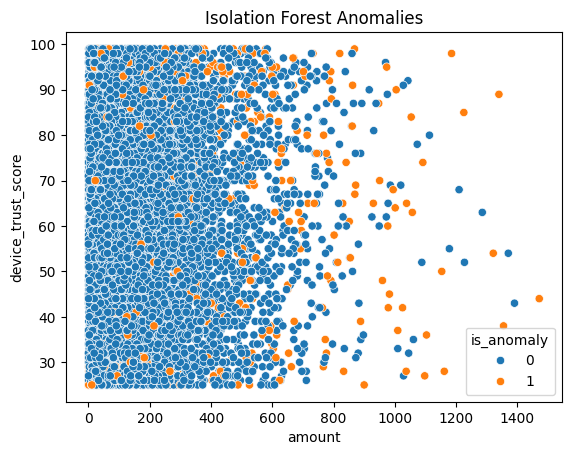

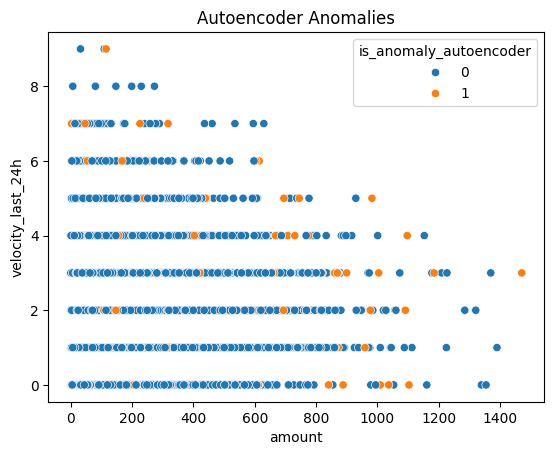

In [15]:
sns.scatterplot(x='amount', y='device_trust_score', hue='is_anomaly', data=df)
plt.title("Isolation Forest Anomalies")
plt.show()

sns.scatterplot(x='amount', y='velocity_last_24h', hue='is_anomaly_autoencoder', data=df)
plt.title("Autoencoder Anomalies")
plt.show()
